# Gaze Synchrony Analysis — Visualization
Visualizes results from `gaze_synchrony_results.csv` across **pre-MOI**, **MOI**, and **post-MOI** windows.

**Metrics:** Pearson r (per axis + mean) · Cosine distance · Peak cross-correlation & lag

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import wilcoxon
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

WINDOWS       = ['pre', 'moi', 'post']
WINDOW_LABELS = {'pre': 'Pre-MOI', 'moi': 'MOI', 'post': 'Post-MOI'}
WINDOW_COLORS = {'pre': '#4878CF', 'moi': '#E24A33', 'post': '#6ACC65'}

In [2]:
# ── Load & fix the merge artifact ─────────────────────────────────────────────
# The raw CSV has a pandas merge artifact: pre data is in _x columns,
# moi data is in _y columns, and post data is in the no-suffix columns.
# We reassemble them here into a clean wide dataframe.

CSV_PATH = 'gaze_synchrony_results.csv'  # adjust path if needed
raw = pd.read_csv(CSV_PATH)

ID_COLS = ['interaction_id', 'annotated_participant', 'event_speaker',
           'participant_a', 'participant_b', 'start_moi', 'end_moi']

METRIC_NAMES = [
    'n_frames',
    'pearson_r_dim0', 'pearson_r_dim1', 'pearson_r_mean',
    'cosine_dist_mean', 'cosine_dist_std', 'cosine_dist_min', 'cosine_dist_max',
    'xcorr_peak', 'xcorr_peak_lag_s',
]

df = raw[ID_COLS].copy()
for m in METRIC_NAMES:
    df[f'pre_{m}']  = raw[f'pre_{m}_x']   # pre landed in _x
    df[f'moi_{m}']  = raw[f'moi_{m}_y']   # moi landed in _y
    df[f'post_{m}'] = raw[f'post_{m}']    # post landed in no-suffix

df['moi_duration'] = df['end_moi'] - df['start_moi']

print(f'Loaded {len(df)} MOI entries from {df["interaction_id"].nunique()} interactions')
print(f'Nulls — pre pearson_r_mean: {df["pre_pearson_r_mean"].isna().sum()} | '
      f'moi: {df["moi_pearson_r_mean"].isna().sum()} | '
      f'post: {df["post_pearson_r_mean"].isna().sum()}')
df.head(3)

Loaded 336 MOI entries from 54 interactions
Nulls — pre pearson_r_mean: 5 | moi: 34 | post: 2


,interaction_id,annotated_participant,event_speaker,participant_a,participant_b,start_moi,end_moi,pre_n_frames,moi_n_frames,post_n_frames,...,pre_cosine_dist_max,moi_cosine_dist_max,post_cosine_dist_max,pre_xcorr_peak,moi_xcorr_peak,post_xcorr_peak,pre_xcorr_peak_lag_s,moi_xcorr_peak_lag_s,post_xcorr_peak_lag_s,moi_duration
0,V00_S1132_I00000333,P1093,P0737,P0737,P1093,26,28,450.0,60.0,450.0,...,2.000000,1.955683,2.00000,-0.012021,-0.061588,0.041892,0.483333,0.416667,1.583333,2
1,V00_S1132_I00000333,P0737,P1093,P0737,P1093,50,52,450.0,60.0,450.0,...,1.999458,1.999608,1.99997,0.055414,-0.396054,0.041873,1.566667,0.516667,0.833333,2
2,V00_S1132_I00000333,P0737,P0737,P0737,P1093,62,66,450.0,120.0,450.0,...,1.999608,1.999970,1.99993,0.189068,-0.452514,-0.017652,-1.833333,-0.366667,0.266667,4


In [3]:
# ── Reshape to long format for seaborn plots ──────────────────────────────────
long_frames = []
for w in WINDOWS:
    tmp = df[ID_COLS + ['moi_duration']].copy()
    for m in METRIC_NAMES:
        tmp[m] = df[f'{w}_{m}']
    tmp['window'] = w
    long_frames.append(tmp)

dfl = pd.concat(long_frames, ignore_index=True)
dfl['window'] = pd.Categorical(dfl['window'], categories=WINDOWS, ordered=True)
print('Long-format shape:', dfl.shape)

Long-format shape: (1008, 19)


---
## 1. Descriptive Statistics

In [4]:
key_metrics = ['pearson_r_mean', 'cosine_dist_mean', 'xcorr_peak', 'xcorr_peak_lag_s']
summary = dfl.groupby('window')[key_metrics].agg(['mean', 'median', 'std', 'count']).round(4)
print('Summary statistics by window:')
summary

Summary statistics by window:


pearson_r_mean                       cosine_dist_mean                  \
                 mean  median     std count             mean  median     std   
window                                                                         
pre            0.0085  0.0040  0.0986   331           0.7434  0.7215  0.3334   
moi           -0.0059 -0.0128  0.1849   302           0.7271  0.6532  0.4330   
post           0.0033  0.0025  0.1006   334           0.7349  0.7203  0.3338   

             xcorr_peak                       xcorr_peak_lag_s          \
       count       mean  median     std count             mean  median   
window                                                                   
pre      331     0.0090 -0.0008  0.1715   331           0.0542  0.0833   
moi      299     0.0248  0.0068  0.3126   302           0.0006 -0.0333   
post     333     0.0144  0.0147  0.1869   334          -0.0157 -0.0333   

                      
           std count  
window                
pre     0.9304   331  
moi     0.7029   302  
post    0.8395   334

---
## 2. Pearson Correlation Across Windows

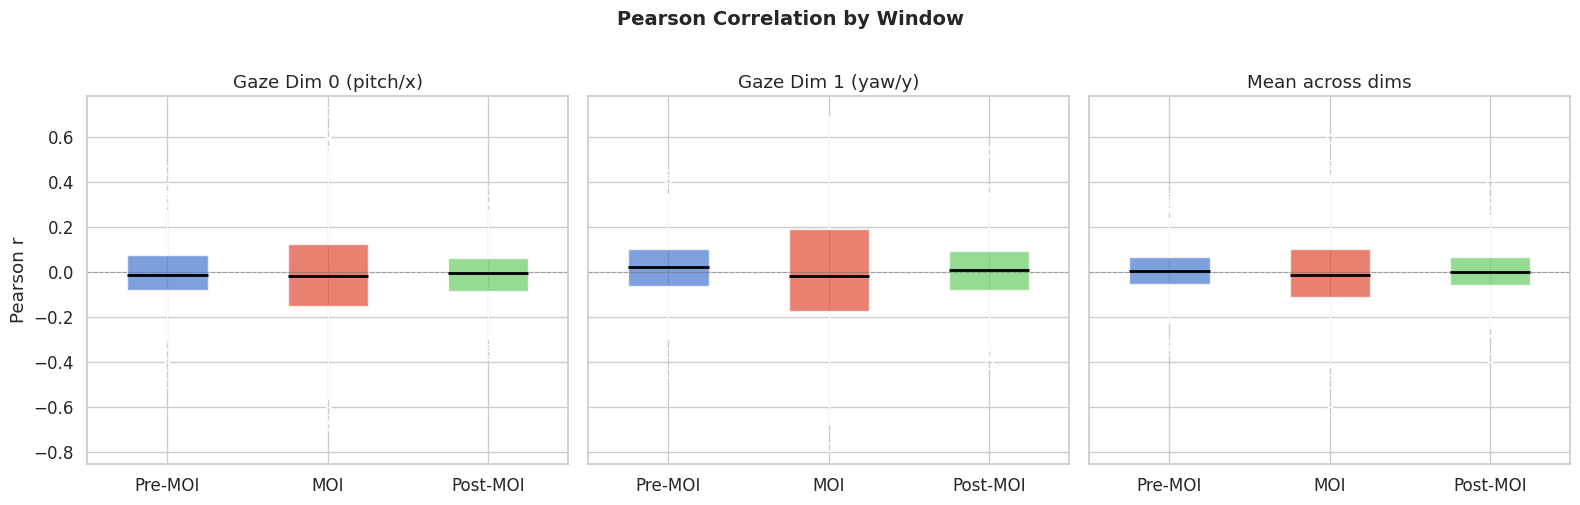

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
fig.suptitle('Pearson Correlation by Window', fontsize=14, fontweight='bold', y=1.01)

for ax, metric, title in zip(
    axes,
    ['pearson_r_dim0', 'pearson_r_dim1', 'pearson_r_mean'],
    ['Gaze Dim 0 (pitch/x)', 'Gaze Dim 1 (yaw/y)', 'Mean across dims']
):
    data = [dfl.loc[dfl['window'] == w, metric].dropna() for w in WINDOWS]
    bp = ax.boxplot(data, patch_artist=True, widths=0.5,
                    medianprops=dict(color='black', linewidth=2))
    for patch, w in zip(bp['boxes'], WINDOWS):
        patch.set_facecolor(WINDOW_COLORS[w])
        patch.set_alpha(0.7)
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels([WINDOW_LABELS[w] for w in WINDOWS])
    ax.set_title(title)
    ax.set_ylabel('Pearson r' if ax is axes[0] else '')
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)

plt.tight_layout()
plt.savefig('fig1_pearson_by_window.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Cosine Distance Across Windows

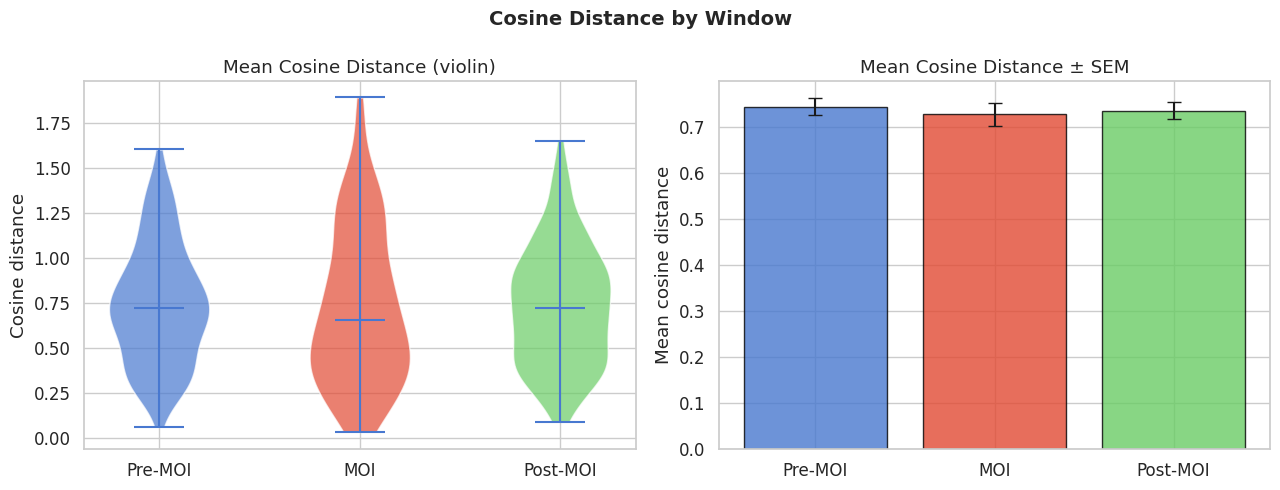

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Cosine Distance by Window', fontsize=14, fontweight='bold')

ax = axes[0]
plot_data = [dfl.loc[dfl['window'] == w, 'cosine_dist_mean'].dropna() for w in WINDOWS]
parts = ax.violinplot(plot_data, positions=[1, 2, 3], showmedians=True)
for pc, w in zip(parts['bodies'], WINDOWS):
    pc.set_facecolor(WINDOW_COLORS[w])
    pc.set_alpha(0.7)
ax.set_xticks([1, 2, 3])
ax.set_xticklabels([WINDOW_LABELS[w] for w in WINDOWS])
ax.set_title('Mean Cosine Distance (violin)')
ax.set_ylabel('Cosine distance')

ax = axes[1]
means = [dfl.loc[dfl['window'] == w, 'cosine_dist_mean'].mean() for w in WINDOWS]
sems  = [dfl.loc[dfl['window'] == w, 'cosine_dist_mean'].sem()  for w in WINDOWS]
ax.bar([WINDOW_LABELS[w] for w in WINDOWS], means, yerr=sems,
       color=[WINDOW_COLORS[w] for w in WINDOWS],
       capsize=5, alpha=0.8, edgecolor='black')
ax.set_title('Mean Cosine Distance ± SEM')
ax.set_ylabel('Mean cosine distance')

plt.tight_layout()
plt.savefig('fig2_cosine_dist_by_window.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Cross-Correlation Peak & Lag

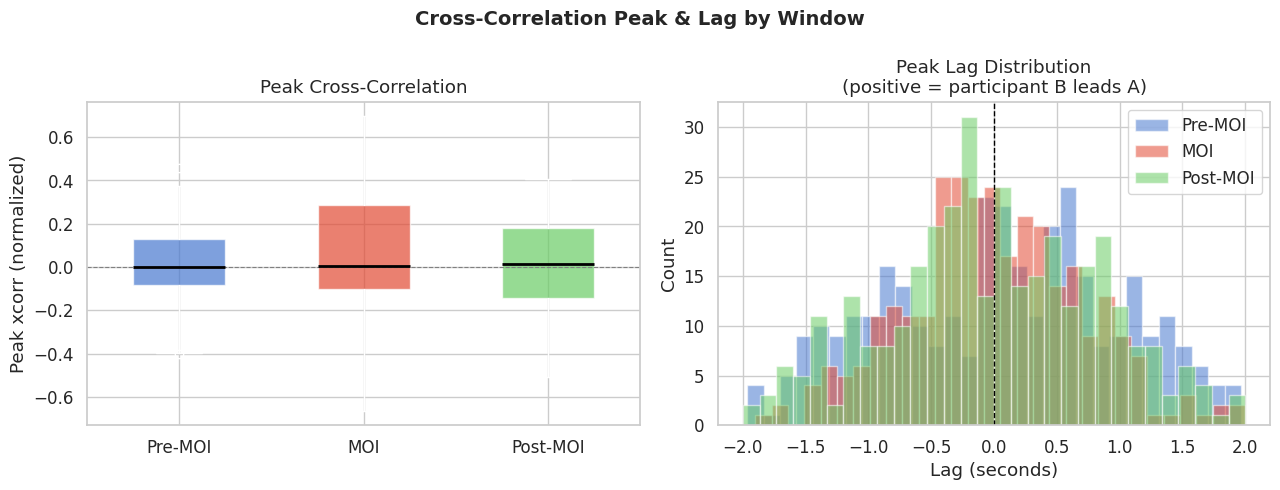

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Cross-Correlation Peak & Lag by Window', fontsize=14, fontweight='bold')

ax = axes[0]
data = [dfl.loc[dfl['window'] == w, 'xcorr_peak'].dropna() for w in WINDOWS]
bp = ax.boxplot(data, patch_artist=True, widths=0.5,
                medianprops=dict(color='black', linewidth=2))
for patch, w in zip(bp['boxes'], WINDOWS):
    patch.set_facecolor(WINDOW_COLORS[w])
    patch.set_alpha(0.7)
ax.set_xticks([1, 2, 3])
ax.set_xticklabels([WINDOW_LABELS[w] for w in WINDOWS])
ax.set_title('Peak Cross-Correlation')
ax.set_ylabel('Peak xcorr (normalized)')
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)

ax = axes[1]
for w in WINDOWS:
    lags = dfl.loc[dfl['window'] == w, 'xcorr_peak_lag_s'].dropna()
    ax.hist(lags, bins=30, alpha=0.55, label=WINDOW_LABELS[w],
            color=WINDOW_COLORS[w], edgecolor='white')
ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.set_title('Peak Lag Distribution\n(positive = participant B leads A)')
ax.set_xlabel('Lag (seconds)')
ax.set_ylabel('Count')
ax.legend()

plt.tight_layout()
plt.savefig('fig3_xcorr_by_window.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Paired Comparison — Per-Interaction Means

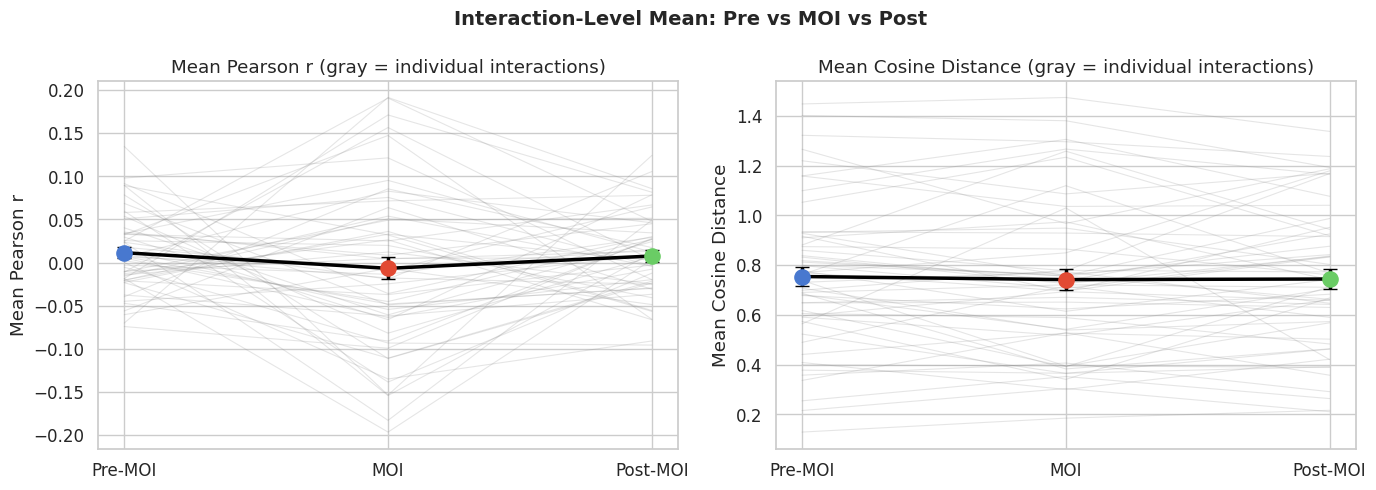

In [8]:
int_summary = dfl.groupby(['interaction_id', 'window'])[key_metrics].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Interaction-Level Mean: Pre vs MOI vs Post', fontsize=14, fontweight='bold')

for ax, metric, ylabel in zip(
    axes,
    ['pearson_r_mean', 'cosine_dist_mean'],
    ['Mean Pearson r', 'Mean Cosine Distance']
):
    pivot = (
        int_summary.pivot(index='interaction_id', columns='window', values=metric)
        [WINDOWS].dropna()
    )
    x_pos = [0, 1, 2]
    for _, row in pivot.iterrows():
        ax.plot(x_pos, row[WINDOWS].values, color='gray', alpha=0.2, linewidth=0.8)
    means = pivot.mean()
    sems  = pivot.sem()
    ax.errorbar(x_pos, means[WINDOWS], yerr=sems[WINDOWS],
                fmt='o-', linewidth=2.5, markersize=8,
                color='black', zorder=5, capsize=5)
    for xi, w in zip(x_pos, WINDOWS):
        ax.scatter(xi, means[w], color=WINDOW_COLORS[w], s=120, zorder=6)
    ax.set_xticks(x_pos)
    ax.set_xticklabels([WINDOW_LABELS[w] for w in WINDOWS])
    ax.set_ylabel(ylabel)
    ax.set_title(f'{ylabel} (gray = individual interactions)')

plt.tight_layout()
plt.savefig('fig4_paired_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Statistical Tests: Pre vs MOI vs Post

In [9]:
print('Wilcoxon signed-rank tests (interaction-level means)\n')
print(f'{"Metric":<22} {"Comparison":<18} {"W":>8}  {"p-value":>10}  Sig.')
print('-' * 68)

for metric in ['pearson_r_mean', 'cosine_dist_mean', 'xcorr_peak']:
    pivot = (
        dfl.groupby(['interaction_id', 'window'])[metric]
        .mean().reset_index()
        .pivot(index='interaction_id', columns='window', values=metric)
        [WINDOWS].dropna()
    )
    for w1, w2 in [('pre', 'moi'), ('moi', 'post'), ('pre', 'post')]:
        try:
            stat, p = wilcoxon(pivot[w1], pivot[w2])
            sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
            print(f'{metric:<22} {w1} vs {w2:<12} {stat:>8.2f}  {p:>10.4f}  {sig}')
        except Exception as e:
            print(f'{metric:<22} {w1} vs {w2:<12} ERROR: {e}')
    print()

Wilcoxon signed-rank tests (interaction-level means)

Metric                 Comparison                W     p-value  Sig.
--------------------------------------------------------------------
pearson_r_mean         pre vs moi            606.00      0.2399  ns
pearson_r_mean         moi vs post           642.00      0.3869  ns
pearson_r_mean         pre vs post           719.00      0.8397  ns

cosine_dist_mean       pre vs moi            634.00      0.3502  ns
cosine_dist_mean       moi vs post           709.00      0.7730  ns
cosine_dist_mean       pre vs post           638.00      0.3682  ns

xcorr_peak             pre vs moi            605.00      0.2365  ns
xcorr_peak             moi vs post           726.00      0.8870  ns
xcorr_peak             pre vs post           654.00      0.4461  ns



---
## 7. Breakdown by Event Speaker (MOI window)

Event speaker distribution (MOI window):
speaker_label
P1118      37
P1122      35
P1119      34
P1120      28
P0430      24
P0071      21
P1121      21
P0317      21
P0737      19
P1123      18
P1093      18
P1019      15
P0518      14
P1109      13
P1110       9
P0709       6
unknown     3


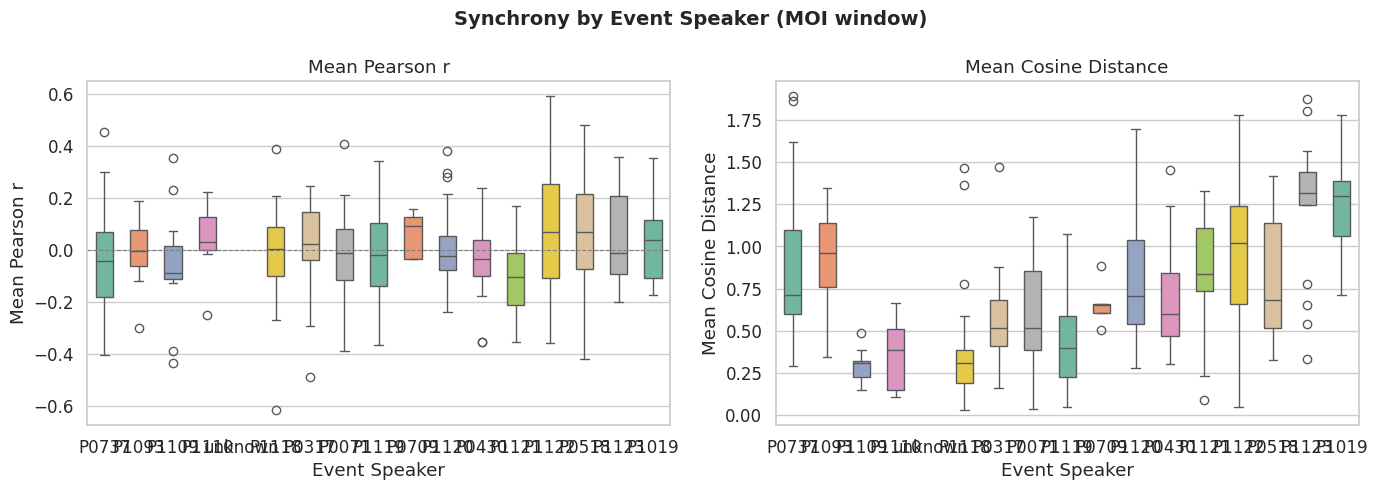

In [10]:
moi_only = dfl[dfl['window'] == 'moi'].copy()
moi_only['speaker_label'] = moi_only['event_speaker'].fillna('unknown')

print('Event speaker distribution (MOI window):')
print(moi_only['speaker_label'].value_counts().to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Synchrony by Event Speaker (MOI window)', fontsize=14, fontweight='bold')

for ax, metric, ylabel in zip(
    axes,
    ['pearson_r_mean', 'cosine_dist_mean'],
    ['Mean Pearson r', 'Mean Cosine Distance']
):
    sns.boxplot(data=moi_only, x='speaker_label', y=metric,
                ax=ax, palette='Set2', width=0.5)
    ax.set_title(ylabel)
    ax.set_xlabel('Event Speaker')
    ax.set_ylabel(ylabel)
    if 'pearson' in metric:
        ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.savefig('fig5_by_speaker.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Heatmap: Per-Interaction Means

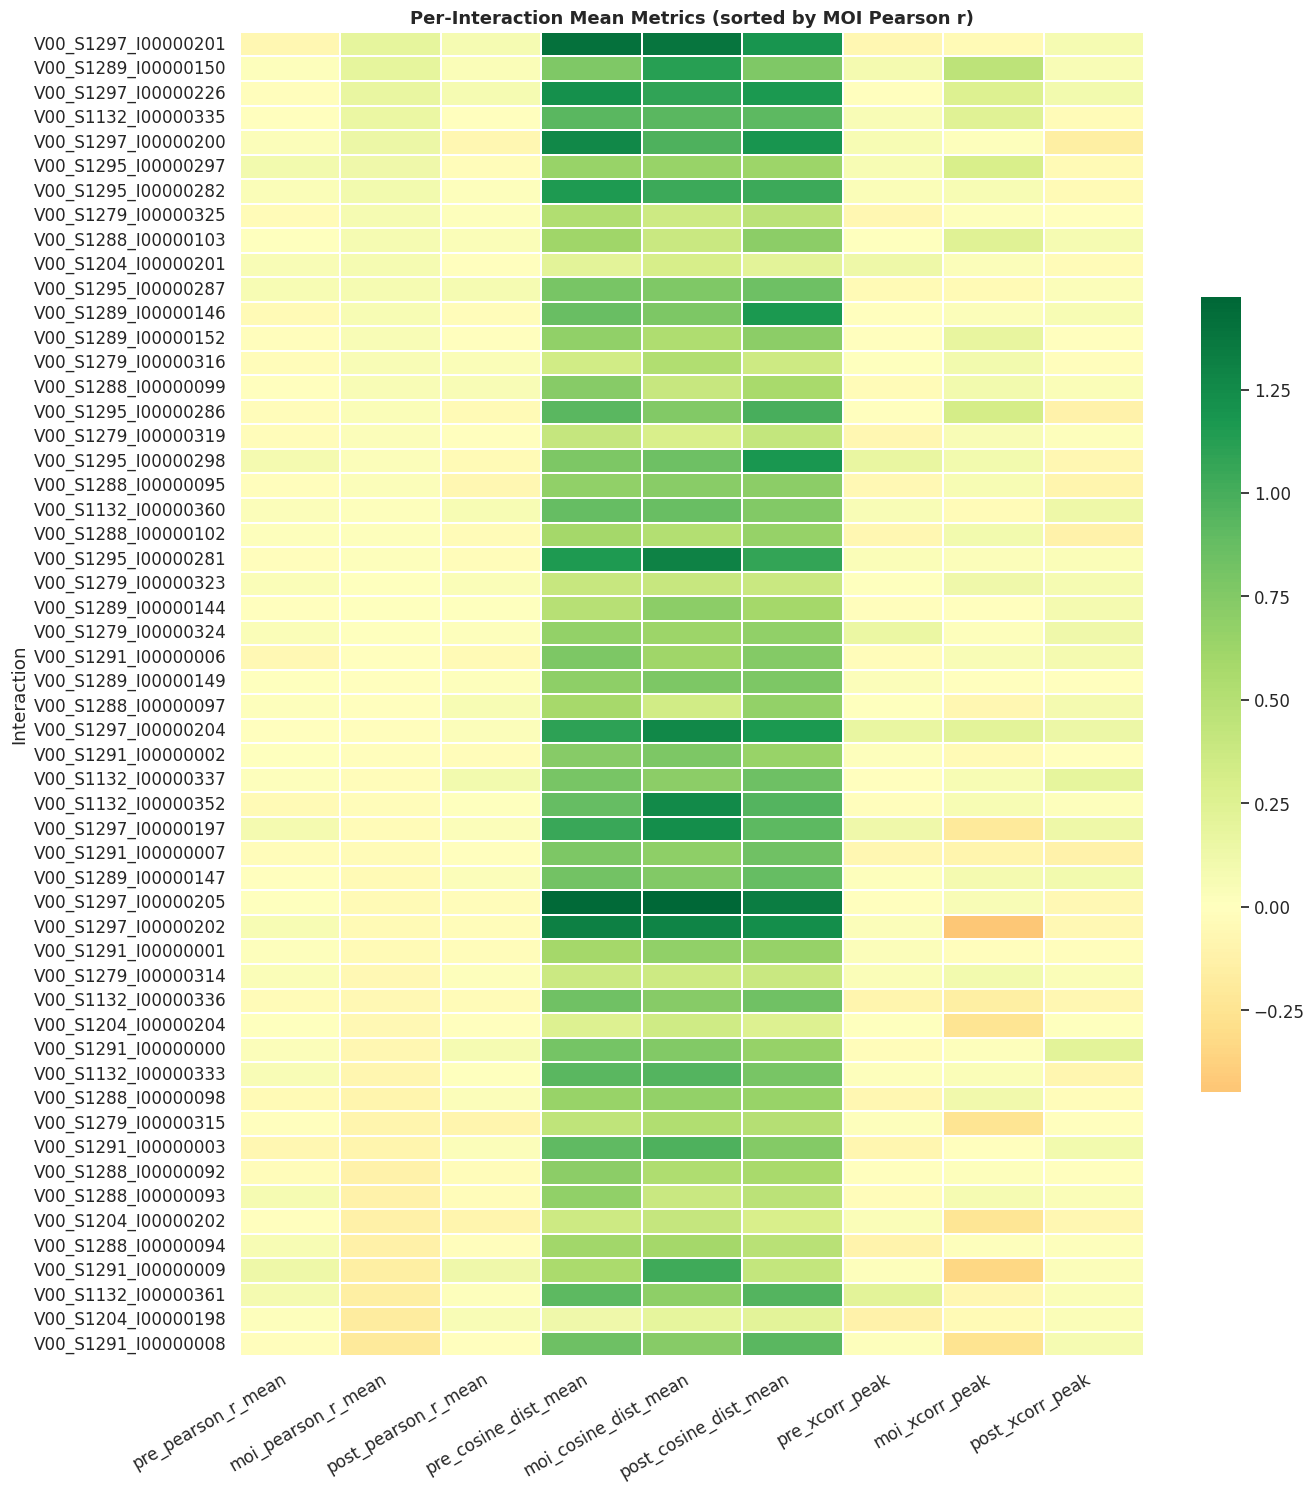

In [11]:
heat_cols = [
    'pre_pearson_r_mean',  'moi_pearson_r_mean',  'post_pearson_r_mean',
    'pre_cosine_dist_mean','moi_cosine_dist_mean','post_cosine_dist_mean',
    'pre_xcorr_peak',      'moi_xcorr_peak',      'post_xcorr_peak',
]
heat_df = (
    df.groupby('interaction_id')[heat_cols].mean()
    .sort_values('moi_pearson_r_mean', ascending=False)
)

fig, ax = plt.subplots(figsize=(14, max(6, len(heat_df) * 0.28)))
sns.heatmap(heat_df, ax=ax, cmap='RdYlGn', center=0,
            linewidths=0.3, linecolor='white', cbar_kws={'shrink': 0.6})
ax.set_title('Per-Interaction Mean Metrics (sorted by MOI Pearson r)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Interaction')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('fig6_heatmap_interactions.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Metric Correlations (MOI window)

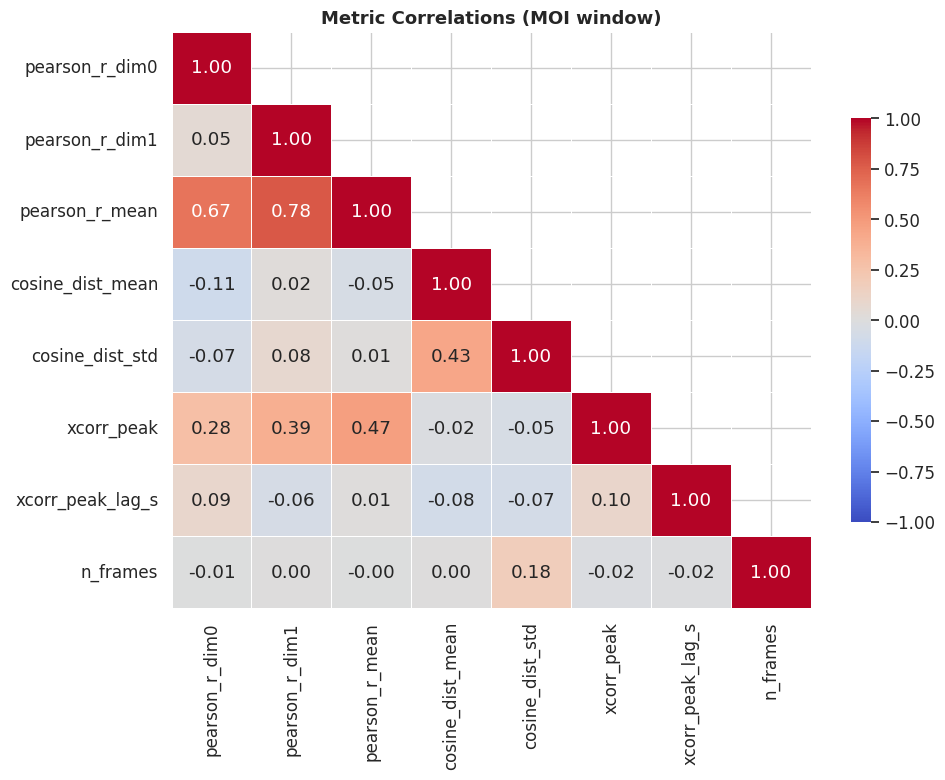

In [12]:
moi_metric_cols = [
    'pearson_r_dim0', 'pearson_r_dim1', 'pearson_r_mean',
    'cosine_dist_mean', 'cosine_dist_std',
    'xcorr_peak', 'xcorr_peak_lag_s', 'n_frames'
]
corr_df = dfl[dfl['window'] == 'moi'][moi_metric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_df, dtype=bool), k=1)
sns.heatmap(corr_df, ax=ax, mask=mask, cmap='coolwarm', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', linewidths=0.5, cbar_kws={'shrink': 0.7})
ax.set_title('Metric Correlations (MOI window)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig7_metric_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. MOI Duration vs Synchrony

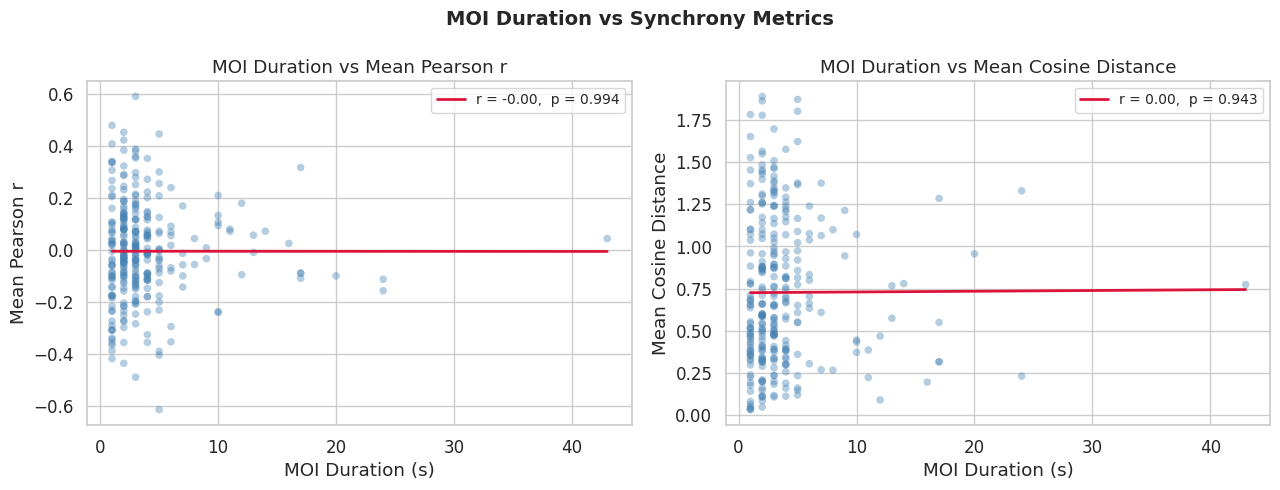

In [13]:
moi_df = dfl[dfl['window'] == 'moi'].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('MOI Duration vs Synchrony Metrics', fontsize=14, fontweight='bold')

for ax, metric, ylabel in zip(
    axes,
    ['pearson_r_mean', 'cosine_dist_mean'],
    ['Mean Pearson r', 'Mean Cosine Distance']
):
    sub = moi_df[['moi_duration', metric]].dropna()
    x, y = sub['moi_duration'], sub[metric]
    ax.scatter(x, y, alpha=0.4, s=30, color='steelblue', edgecolors='none')
    if len(x) > 2:
        m_coef, b, r, p, _ = stats.linregress(x, y)
        xline = np.linspace(x.min(), x.max(), 100)
        ax.plot(xline, m_coef * xline + b, color='crimson', linewidth=2,
                label=f'r = {r:.2f},  p = {p:.3f}')
        ax.legend(fontsize=10)
    ax.set_xlabel('MOI Duration (s)')
    ax.set_ylabel(ylabel)
    ax.set_title(f'MOI Duration vs {ylabel}')

plt.tight_layout()
plt.savefig('fig8_duration_vs_synchrony.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 11. Summary Dashboard

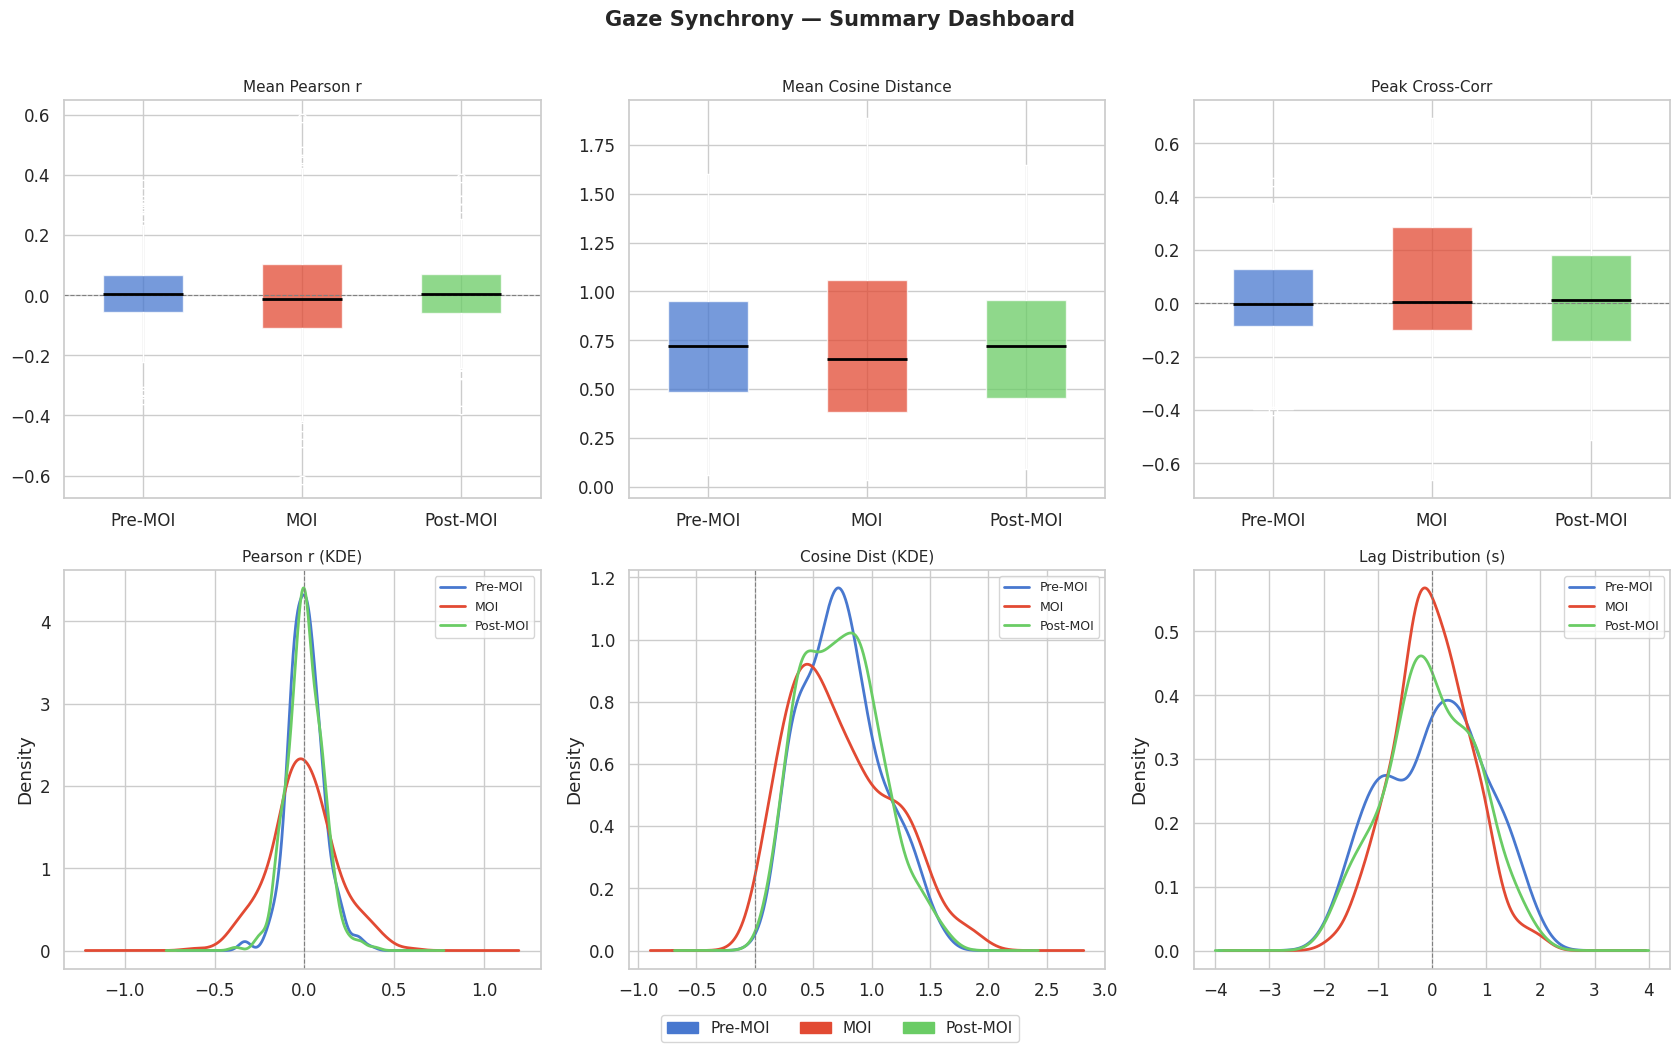

All figures saved.


In [14]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle('Gaze Synchrony — Summary Dashboard', fontsize=15, fontweight='bold', y=1.01)

plot_specs = [
    ('pearson_r_mean',   'Mean Pearson r',       'boxplot'),
    ('cosine_dist_mean', 'Mean Cosine Distance',  'boxplot'),
    ('xcorr_peak',       'Peak Cross-Corr',       'boxplot'),
    ('pearson_r_mean',   'Pearson r (KDE)',        'kde'),
    ('cosine_dist_mean', 'Cosine Dist (KDE)',      'kde'),
    ('xcorr_peak_lag_s', 'Lag Distribution (s)',  'kde'),
]

for ax, (metric, title, kind) in zip(axes.flat, plot_specs):
    if kind == 'boxplot':
        data = [dfl.loc[dfl['window'] == w, metric].dropna() for w in WINDOWS]
        bp = ax.boxplot(data, patch_artist=True, widths=0.5,
                        medianprops=dict(color='black', linewidth=2))
        for patch, w in zip(bp['boxes'], WINDOWS):
            patch.set_facecolor(WINDOW_COLORS[w])
            patch.set_alpha(0.75)
        ax.set_xticks([1, 2, 3])
        ax.set_xticklabels([WINDOW_LABELS[w] for w in WINDOWS])
        if metric in ('pearson_r_mean', 'xcorr_peak'):
            ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    else:
        for w in WINDOWS:
            vals = dfl.loc[dfl['window'] == w, metric].dropna()
            if len(vals) > 2:
                vals.plot.kde(ax=ax, label=WINDOW_LABELS[w],
                              color=WINDOW_COLORS[w], linewidth=2)
        ax.axvline(0, color='gray', linestyle='--', linewidth=0.8)
        ax.legend(fontsize=9)
    ax.set_title(title, fontsize=11)

patches = [mpatches.Patch(color=WINDOW_COLORS[w], label=WINDOW_LABELS[w]) for w in WINDOWS]
fig.legend(handles=patches, loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, -0.03), fontsize=11)

plt.tight_layout()
plt.savefig('fig9_summary_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('All figures saved.')